# Model Training v3 — Speaker-Level Grouped Pipeline

This v3 notebook implements the higher-impact changes from v2 diagnostics:
- **Speaker-level aggregation** across all available tokens
- **Multi-token setup** (`SELECTED_TOKEN=None`) to reduce utterance noise
- **Grouped cross-validation model search** with `StratifiedGroupKFold`
- **Feature-size search** (`SelectKBest(k)`) instead of fixed `k=50`
- **Binary threshold tuning** for better macro-F1 / balanced accuracy

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append('..')
from src.features import FeatureOptions, load_feature_tables

In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Keep all tokens, then aggregate per speaker
SELECTED_TOKEN = None

# Class filtering (applied after grouping)
MIN_SAMPLES_PER_CLASS = 50
MAX_SAMPLES_PER_CLASS = 500

# Balance healthy against total pathological pool
BALANCE_HEALTHY_TO_PATHOLOGICAL = True
UPSAMPLE_HEALTHY_TO_PATHOLOGICAL = True

# Grouped CV + feature size search
N_SPLITS = 5
K_CANDIDATES = [30, 50, 100, 150, 200]
THRESHOLD_GRID = np.linspace(0.20, 0.80, 25)

TARGET_SOURCE_COL_PREFERENCE = 'pathology_de'
USE_GROUPED_TARGET = True
KEEP_UNMAPPED_LABELS = True
UNMAPPED_LABEL = 'Other'

DISEASE_GROUP_MAP = {
    # --- NEUROLOGICAL ---
    'Morbus Parkinson': 'Neurological',
    'Rekurrensparese': 'Neurological',
    'Spasmodische Dysphonie': 'Neurological',

    # --- STRUCTURAL ---
    'Phonationsknötchen': 'Structural',
    'Stimmlippenpolyp': 'Structural',
    'Reinke Ödem': 'Structural',
    'Laryngitis': 'Structural',


    # --- FUNCTIONAL ---
    'Hypotone Dysphonie': 'Functional',
    'Hyperfunktionelle Dysphonie': 'Functional',

    # --- REDUNDANT ---
    'Phonationsknötchen': 'Structural',
    'Reinke Ödem': 'Structural',
}

opts = FeatureOptions(
    prefix=Path('..'),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    balance_healthy_to_pathological=BALANCE_HEALTHY_TO_PATHOLOGICAL,
    upsample_healthy_to_pathological=UPSAMPLE_HEALTHY_TO_PATHOLOGICAL,
    selected_token=SELECTED_TOKEN,
)
opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=500, balance_healthy_to_pathological=True, upsample_healthy_to_pathological=True, normalize_audio=True, target_sample_rate=None, selected_token=None, mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [ ]:
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

for name, tdf in tables.items():
    print(f'{name}: {tdf.shape}')

core_df = tables['core'].copy()
acoustic_df = tables['acoustic'].copy()
multifractal_df = tables['multifractal'].copy()
opensmile_df = tables.get('opensmile', pd.DataFrame()).copy()
splits_df = tables.get('splits', pd.DataFrame()).copy()

df = core_df.merge(acoustic_df, on='sample_key', how='left')
df = df.merge(multifractal_df, on='sample_key', how='left')
if not opensmile_df.empty:
    df = df.merge(opensmile_df, on='sample_key', how='left')
if not splits_df.empty:
    df = df.merge(splits_df, on='sample_key', how='left')

if 'feature_status' in df.columns:
    df = df[df['feature_status'].isin(['ok', 'partial_failure'])].copy()
if 'acoustic_status' in df.columns:
    df = df[df['acoustic_status'] == 'ok'].copy()
if 'mf_status' in df.columns:
    df = df[df['mf_status'] == 'ok'].copy()
if 'opensmile_status' in df.columns:
    df = df[df['opensmile_status'] == 'ok'].copy()

print('Merged sample-level shape:', df.shape)
print('Unique speakers (sample level):', df['speaker_id'].nunique())

Pathologies:   0%|          | 0/3 [00:00<?, ?pathology/s]

Hyperfunktionelle Dysphonie recordings:   0%|          | 0/213 [00:00<?, ?recording/s]

Hyperfunktionelle Dysphonie/106 files:   0%|          | 0/14 [00:00<?, ?file/s]

Hyperfunktionelle Dysphonie/127 files:   0%|          | 0/14 [00:00<?, ?file/s]

Hyperfunktionelle Dysphonie/140 files:   0%|          | 0/14 [00:00<?, ?file/s]

...

Laryngitis/2600 files:   0%|          | 0/14 [00:00<?, ?file/s]

Laryngitis/2602 files:   0%|          | 0/14 [00:00<?, ?file/s]

Laryngitis/2605 files:   0%|          | 0/14 [00:00<?, ?file/s]

Laryngitis/2610 files:   0%|          | 0/14 [00:00<?, ?file/s]

Extracting features:   0%|          | 0/6642 [00:00<?, ?sample/s]

In [ ]:
# Build target labels
if TARGET_SOURCE_COL_PREFERENCE in df.columns:
    target_source_col = TARGET_SOURCE_COL_PREFERENCE
elif 'pathology_en' in df.columns:
    target_source_col = 'pathology_en'
elif 'pathology_de' in df.columns:
    target_source_col = 'pathology_de'
else:
    raise ValueError('Could not find pathology label column (expected pathology_de/pathology_en).')

raw_target = df[target_source_col].astype(str).str.strip()
if USE_GROUPED_TARGET:
    mapped_target = raw_target.map(DISEASE_GROUP_MAP)
    if KEEP_UNMAPPED_LABELS:
        mapped_target = mapped_target.fillna(raw_target)
    else:
        mapped_target = mapped_target.fillna(UNMAPPED_LABEL)
    df['target_label'] = mapped_target.astype(str)
else:
    df['target_label'] = raw_target

target_col = 'target_label'

print('Target source:', target_source_col)
print('Grouped target enabled:', USE_GROUPED_TARGET)
display(df[target_col].value_counts().to_frame('sample_count_before_filter'))

small_classes = df[target_col].value_counts()[df[target_col].value_counts() < MIN_SAMPLES_PER_CLASS].index.tolist()
if small_classes:
    print(f'Dropping classes with < {MIN_SAMPLES_PER_CLASS} samples: {small_classes}')
    df = df[~df[target_col].isin(small_classes)].copy()

display(df[target_col].value_counts().to_frame('sample_count_after_filter'))

Target source: pathology_de
Grouped target enabled: True


,sample_count_before_filter
target_label,
Structural,1237
Neurological,1014
healthy,500


,sample_count_after_filter
target_label,
Structural,1237
Neurological,1014
healthy,500


In [ ]:
# Speaker-level aggregation
meta_cols = {
    'sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id', 'wav_path',
    'feature_status', 'feature_error', 'acoustic_status', 'acoustic_error',
    'mf_status', 'mf_error', 'opensmile_status', 'opensmile_error',
    'split', 'split_seed', 'pathology_de', 'pathology_en', target_col, 'is_healthy',
}

numeric_feature_cols = [
    c for c in df.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(df[c])
]

agg_stats = ['mean', 'std', 'median']
num_agg = df.groupby('speaker_id')[numeric_feature_cols].agg(agg_stats)
num_agg.columns = [f'{col}__{stat}' for col, stat in num_agg.columns]

speaker_meta = df.groupby('speaker_id').agg({
    'sex': 'first',
    'is_healthy': lambda s: int(round(float(s.mean()))),
    target_col: lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0],
    'pathology_de': lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0],
    'pathology_en': lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0],
    'recording_id': 'nunique',
    'token': 'nunique',
}).rename(columns={'recording_id': 'n_recordings', 'token': 'n_tokens'})

speaker_df = speaker_meta.join(num_agg, how='inner').reset_index()

# Replace NaN std for single-observation speakers
std_cols = [c for c in speaker_df.columns if c.endswith('__std')]
if std_cols:
    speaker_df[std_cols] = speaker_df[std_cols].fillna(0.0)

print('Speaker-level shape:', speaker_df.shape)
display(speaker_df[[target_col, 'is_healthy', 'n_tokens', 'n_recordings']].head())
display(speaker_df[target_col].value_counts().to_frame('speaker_count_by_class'))

Speaker-level shape: (615, 581)


C:\Users\mnand\AppData\Local\Temp\ipykernel_2352\2459247305.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  speaker_df = speaker_meta.join(num_agg, how='inner').reset_index()


,target_label,is_healthy,n_tokens,n_recordings
0,healthy,1,2,1
1,healthy,1,1,1
2,healthy,1,2,1
3,healthy,1,2,1
4,healthy,1,1,1


,speaker_count_by_class
target_label,
healthy,358
Neurological,154
Structural,103


In [ ]:
# Model-ready matrices (speaker level)
feature_exclude = {'speaker_id', 'is_healthy', target_col, 'pathology_de', 'pathology_en'}
speaker_numeric_cols = [
    c for c in speaker_df.columns if c not in feature_exclude and pd.api.types.is_numeric_dtype(speaker_df[c])
]
speaker_categorical_cols = ['sex'] if 'sex' in speaker_df.columns else []

X_spk = speaker_df[speaker_numeric_cols + speaker_categorical_cols].copy()
y_bin_spk = speaker_df['is_healthy'].astype(int).copy()
y_multi_spk = speaker_df[target_col].astype(str).copy()
groups_spk = speaker_df['speaker_id'].astype(str).copy()

print('Speakers:', len(speaker_df))
print('Binary classes:', y_bin_spk.value_counts().to_dict())
print('Multi classes:', y_multi_spk.value_counts().to_dict())
print('Numeric features:', len(speaker_numeric_cols))
print('Categorical features:', speaker_categorical_cols)

Speakers: 615
Binary classes: {1: 358, 0: 257}
Multi classes: {'healthy': 358, 'Neurological': 154, 'Structural': 103}
Numeric features: 575
Categorical features: ['sex']


In [ ]:
# Shared preprocessing + pipeline builder
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('variance', VarianceThreshold(threshold=0.0)),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, speaker_numeric_cols),
        ('cat', categorical_transformer, speaker_categorical_cols),
    ],
    remainder='drop',
)

def make_pipe(model, k):
    return Pipeline(steps=[
        ('prep', preprocessor),
        ('selector', SelectKBest(f_classif, k=k)),
        ('model', model),
    ])

In [ ]:
# Binary CV with per-fold threshold tuning
def evaluate_binary_grouped_cv(model, k, X, y, groups, n_splits=5, threshold_grid=None):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    threshold_grid = THRESHOLD_GRID if threshold_grid is None else threshold_grid

    fold_rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        pipe = make_pipe(clone(model), k)
        pipe.fit(X_tr, y_tr)

        # Tune threshold on train probabilities only (no test leakage)
        p_tr = pipe.predict_proba(X_tr)[:, 1]
        best_thr, best_f1 = 0.5, -1.0
        for thr in threshold_grid:
            pred_tr = (p_tr >= thr).astype(int)
            f1m = f1_score(y_tr, pred_tr, average='macro', zero_division=0)
            if f1m > best_f1:
                best_f1 = f1m
                best_thr = float(thr)

        p_te = pipe.predict_proba(X_te)[:, 1]
        pred_te = (p_te >= best_thr).astype(int)

        fold_rows.append({
            'fold': fold,
            'threshold': best_thr,
            'accuracy': accuracy_score(y_te, pred_te),
            'balanced_accuracy': balanced_accuracy_score(y_te, pred_te),
            'f1_macro': f1_score(y_te, pred_te, average='macro', zero_division=0),
        })

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        'accuracy_mean': fold_df['accuracy'].mean(),
        'accuracy_std': fold_df['accuracy'].std(),
        'balanced_accuracy_mean': fold_df['balanced_accuracy'].mean(),
        'balanced_accuracy_std': fold_df['balanced_accuracy'].std(),
        'f1_macro_mean': fold_df['f1_macro'].mean(),
        'f1_macro_std': fold_df['f1_macro'].std(),
        'threshold_mean': fold_df['threshold'].mean(),
        'threshold_std': fold_df['threshold'].std(),
    }
    return fold_df, summary

In [ ]:
binary_models = {
    'LogReg': LogisticRegression(max_iter=6000, class_weight='balanced', random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(
        n_estimators=500, max_depth=None, class_weight='balanced_subsample',
        random_state=RANDOM_SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.85, colsample_bytree=0.8,
        random_state=RANDOM_SEED, n_jobs=-1, eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
    ),
}

bin_rows = []
for k in K_CANDIDATES:
    for model_name, model in binary_models.items():
        fold_df, summ = evaluate_binary_grouped_cv(model, k, X_spk, y_bin_spk, groups_spk, n_splits=N_SPLITS)
        bin_rows.append({
            'model': model_name,
            'k': k,
            **summ,
        })

bin_results = pd.DataFrame(bin_rows).sort_values(
    by=['f1_macro_mean', 'balanced_accuracy_mean'], ascending=False
).reset_index(drop=True)

display(bin_results.head(15))
best_bin_cfg = bin_results.iloc[0].to_dict()
print('Best binary config:', best_bin_cfg)

g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

,model,k,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,threshold_mean,threshold_std
0,LightGBM,200,0.889431,0.046562,0.874590,0.052313,0.882426,0.050726,0.200,0.000000
1,XGBoost,200,0.886179,0.047056,0.867942,0.053938,0.877542,0.051950,0.235,0.022361
2,RandomForest,200,0.884553,0.044307,0.865466,0.051913,0.875322,0.049914,0.405,0.011180
3,LogReg,200,0.874797,0.040487,0.867120,0.045979,0.869616,0.043621,0.505,0.099058
4,LightGBM,100,0.878049,0.034011,0.858766,0.039947,0.868775,0.038565,0.200,0.000000
5,LogReg,150,0.868293,0.050249,0.859084,0.058562,0.861990,0.055233,0.465,0.100933
6,XGBoost,100,0.871545,0.033224,0.849911,0.038464,0.860888,0.037693,0.200,0.000000
7,LightGBM,50,0.866667,0.029650,0.847439,0.034400,0.856924,0.033698,0.200,0.000000
8,LightGBM,30,0.856911,0.034301,0.838590,0.038019,0.847123,0.038302,0.200,0.000000
9,LightGBM,150,0.853659,0.035901,0.843608,0.041687,0.846729,0.038511,0.390,0.174642


Best binary config: {'model': 'LightGBM', 'k': 200, 'accuracy_mean': 0.8894308943089431, 'accuracy_std': 0.046562019717971866, 'balanced_accuracy_mean': 0.8745900870279495, 'balanced_accuracy_std': 0.052313447284681576, 'f1_macro_mean': 0.8824264824317808, 'f1_macro_std': 0.05072612514723485, 'threshold_mean': 0.2, 'threshold_std': 0.0}


In [ ]:
# Multi-class (pathological only) grouped CV search
X_patho = X_spk[y_bin_spk == 0].copy()
y_patho = y_multi_spk[y_bin_spk == 0].copy()
g_patho = groups_spk[y_bin_spk == 0].copy()

multi_models = {
    'SVM-RBF': SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced'),
    'RandomForest': RandomForestClassifier(
        n_estimators=500, class_weight='balanced_subsample', random_state=RANDOM_SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.85, colsample_bytree=0.8,
        random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
    ),
}

cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
multi_rows = []
for k in K_CANDIDATES:
    for model_name, model in multi_models.items():
        fold_metrics = []
        for tr, te in cv.split(X_patho, y_patho, g_patho):
            X_tr, X_te = X_patho.iloc[tr], X_patho.iloc[te]
            y_tr, y_te = y_patho.iloc[tr], y_patho.iloc[te]

            le = LabelEncoder()
            y_tr_enc = le.fit_transform(y_tr)
            y_te_enc = le.transform(y_te)

            pipe = make_pipe(clone(model), k)
            pipe.fit(X_tr, y_tr_enc)
            pred_enc = pipe.predict(X_te)

            fold_metrics.append({
                'accuracy': accuracy_score(y_te_enc, pred_enc),
                'balanced_accuracy': balanced_accuracy_score(y_te_enc, pred_enc),
                'f1_macro': f1_score(y_te_enc, pred_enc, average='macro', zero_division=0),
            })

        fold_df = pd.DataFrame(fold_metrics)
        multi_rows.append({
            'model': model_name,
            'k': k,
            'accuracy_mean': fold_df['accuracy'].mean(),
            'accuracy_std': fold_df['accuracy'].std(),
            'balanced_accuracy_mean': fold_df['balanced_accuracy'].mean(),
            'balanced_accuracy_std': fold_df['balanced_accuracy'].std(),
            'f1_macro_mean': fold_df['f1_macro'].mean(),
            'f1_macro_std': fold_df['f1_macro'].std(),
        })

multi_results = pd.DataFrame(multi_rows).sort_values(
    by=['f1_macro_mean', 'balanced_accuracy_mean'], ascending=False
).reset_index(drop=True)

display(multi_results.head(15))
best_multi_cfg = multi_results.iloc[0].to_dict()
print('Best multi-class config:', best_multi_cfg)

g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

KeyboardInterrupt: 

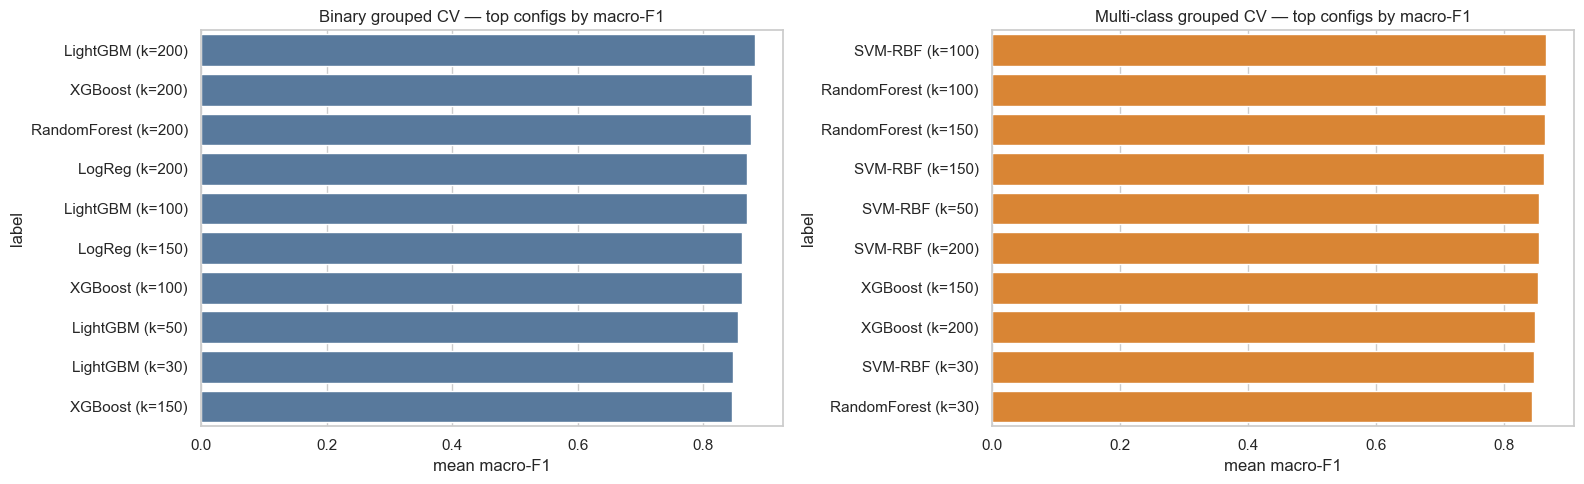

In [ ]:
# Plot top configs
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_bin_plot = bin_results.head(10).copy()
top_bin_plot['label'] = top_bin_plot['model'] + ' (k=' + top_bin_plot['k'].astype(str) + ')'
sns.barplot(data=top_bin_plot, x='f1_macro_mean', y='label', ax=axes[0], color='#4C78A8')
axes[0].set_title('Binary grouped CV — top configs by macro-F1')
axes[0].set_xlabel('mean macro-F1')

top_multi_plot = multi_results.head(10).copy()
top_multi_plot['label'] = top_multi_plot['model'] + ' (k=' + top_multi_plot['k'].astype(str) + ')'
sns.barplot(data=top_multi_plot, x='f1_macro_mean', y='label', ax=axes[1], color='#F58518')
axes[1].set_title('Multi-class grouped CV — top configs by macro-F1')
axes[1].set_xlabel('mean macro-F1')

plt.tight_layout()
plt.show()

## How to use this notebook

1. Run all cells top-to-bottom.
2. Compare v3 grouped-CV means/stdev against v2 single-split metrics.
3. Start from `best_bin_cfg` and `best_multi_cfg` for final refits / reporting.
4. If needed, tighten `K_CANDIDATES` around the best `k` and rerun for faster iteration.

=== BEST CONFIG ROWS (exported as DataFrames in memory) ===
best_bin_row variable:


,model,k,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,threshold_mean,threshold_std
0,LightGBM,200,0.889431,0.046562,0.87459,0.052313,0.882426,0.050726,0.2,0.0


best_multi_row variable:


,model,k,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std
0,SVM-RBF,100,0.871418,0.049218,0.867304,0.046108,0.866193,0.050347


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur


=== BEST BINARY CONFIG: OOF METRICS ===
model=LightGBM, k=200
      fold  threshold  accuracy  balanced_accuracy  f1_macro
mean   3.0        0.2    0.8894             0.8746    0.8824
       fold  threshold  accuracy  balanced_accuracy  f1_macro
std  1.5811        0.0    0.0466             0.0523    0.0507

Binary classification report (OOF):
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       257
           1       0.86      0.96      0.91       358

    accuracy                           0.89       615
   macro avg       0.90      0.87      0.88       615
weighted avg       0.89      0.89      0.89       615

Binary confusion matrix (OOF):


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,pred_0,pred_1
true_0,202,55
true_1,13,345



=== BEST MULTI-CLASS CONFIG: OOF METRICS ===
model=SVM-RBF, k=100
      fold  accuracy  balanced_accuracy  f1_macro
mean   3.0    0.8714             0.8673    0.8662
       fold  accuracy  balanced_accuracy  f1_macro
std  1.5811    0.0492             0.0461    0.0503

Multi-class classification report (OOF):
              precision    recall  f1-score   support

Neurological       0.90      0.89      0.89       154
  Structural       0.84      0.84      0.84       103

    accuracy                           0.87       257
   macro avg       0.87      0.87      0.87       257
weighted avg       0.87      0.87      0.87       257

Multi-class confusion matrix (OOF):


,pred_Neurological,pred_Structural
true_Neurological,137,17
true_Structural,16,87


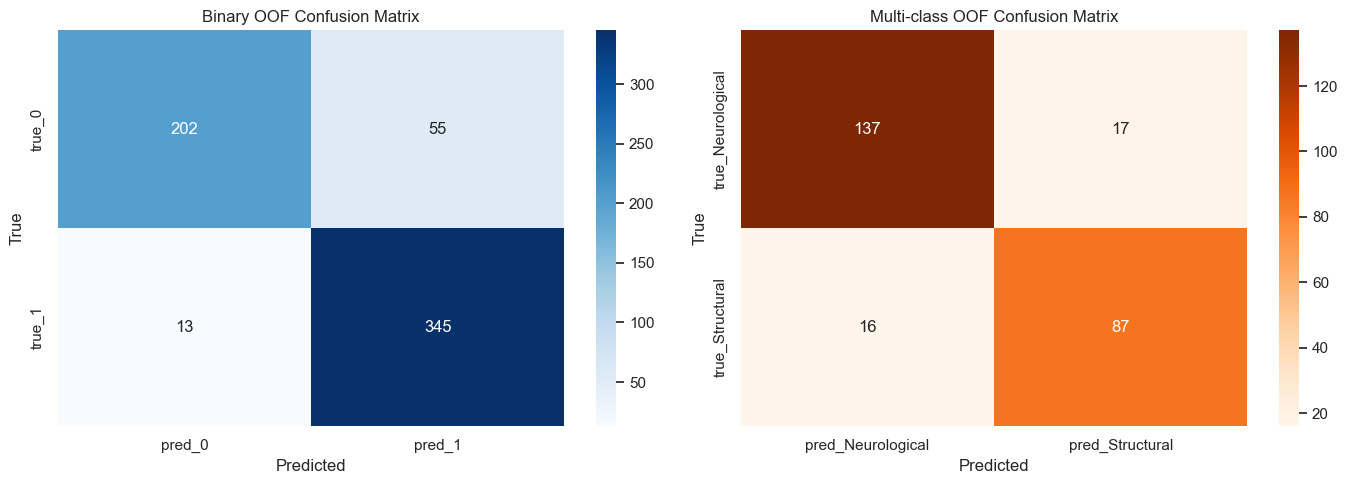

In [ ]:
# Final report: best config rows + OOF metrics + confusion matrices (no file export)
from sklearn.metrics import classification_report, confusion_matrix

# --- 1) Export (in-memory) best config rows ---
best_bin_row = (
    bin_results[
        (bin_results['model'] == best_bin_cfg['model']) &
        (bin_results['k'] == best_bin_cfg['k'])
    ]
    .head(1)
    .copy()
)

best_multi_row = (
    multi_results[
        (multi_results['model'] == best_multi_cfg['model']) &
        (multi_results['k'] == best_multi_cfg['k'])
    ]
    .head(1)
    .copy()
)

print('=== BEST CONFIG ROWS (exported as DataFrames in memory) ===')
print('best_bin_row variable:')
display(best_bin_row)
print('best_multi_row variable:')
display(best_multi_row)

# --- 2) Recompute out-of-fold predictions for the BEST binary config ---
best_bin_model_name = best_bin_cfg['model']
best_bin_k = int(best_bin_cfg['k'])
best_bin_model = clone(binary_models[best_bin_model_name])

cv_bin = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

y_true_bin_all, y_pred_bin_all = [], []
fold_rows_bin = []

for fold, (tr, te) in enumerate(cv_bin.split(X_spk, y_bin_spk, groups_spk), start=1):
    X_tr, X_te = X_spk.iloc[tr], X_spk.iloc[te]
    y_tr, y_te = y_bin_spk.iloc[tr], y_bin_spk.iloc[te]

    pipe = make_pipe(clone(best_bin_model), best_bin_k)
    pipe.fit(X_tr, y_tr)

    p_tr = pipe.predict_proba(X_tr)[:, 1]
    best_thr, best_f1_train = 0.5, -1.0
    for thr in THRESHOLD_GRID:
        pred_tr = (p_tr >= thr).astype(int)
        f1_train = f1_score(y_tr, pred_tr, average='macro', zero_division=0)
        if f1_train > best_f1_train:
            best_f1_train = f1_train
            best_thr = float(thr)

    p_te = pipe.predict_proba(X_te)[:, 1]
    pred_te = (p_te >= best_thr).astype(int)

    y_true_bin_all.extend(y_te.tolist())
    y_pred_bin_all.extend(pred_te.tolist())

    fold_rows_bin.append({
        'fold': fold,
        'threshold': best_thr,
        'accuracy': accuracy_score(y_te, pred_te),
        'balanced_accuracy': balanced_accuracy_score(y_te, pred_te),
        'f1_macro': f1_score(y_te, pred_te, average='macro', zero_division=0),
    })

bin_fold_report = pd.DataFrame(fold_rows_bin)

print('\n=== BEST BINARY CONFIG: OOF METRICS ===')
print(f"model={best_bin_model_name}, k={best_bin_k}")
print((bin_fold_report.mean(numeric_only=True).round(4)).to_frame('mean').T)
print((bin_fold_report.std(numeric_only=True).round(4)).to_frame('std').T)

print('\nBinary classification report (OOF):')
print(classification_report(y_true_bin_all, y_pred_bin_all, zero_division=0))

cm_bin = confusion_matrix(y_true_bin_all, y_pred_bin_all, labels=[0, 1])
cm_bin_df = pd.DataFrame(cm_bin, index=['true_0', 'true_1'], columns=['pred_0', 'pred_1'])
print('Binary confusion matrix (OOF):')
display(cm_bin_df)

# --- 3) Recompute out-of-fold predictions for the BEST multi-class config (pathological only) ---
best_multi_model_name = best_multi_cfg['model']
best_multi_k = int(best_multi_cfg['k'])
best_multi_model = clone(multi_models[best_multi_model_name])

cv_multi = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

y_true_multi_all, y_pred_multi_all = [], []
fold_rows_multi = []

for fold, (tr, te) in enumerate(cv_multi.split(X_patho, y_patho, g_patho), start=1):
    X_tr, X_te = X_patho.iloc[tr], X_patho.iloc[te]
    y_tr, y_te = y_patho.iloc[tr], y_patho.iloc[te]

    le = LabelEncoder()
    y_tr_enc = le.fit_transform(y_tr)

    pipe = make_pipe(clone(best_multi_model), best_multi_k)
    pipe.fit(X_tr, y_tr_enc)

    pred_enc = pipe.predict(X_te)
    pred_lbl = le.inverse_transform(pred_enc)

    y_true_multi_all.extend(y_te.astype(str).tolist())
    y_pred_multi_all.extend(pd.Series(pred_lbl).astype(str).tolist())

    fold_rows_multi.append({
        'fold': fold,
        'accuracy': accuracy_score(y_te, pred_lbl),
        'balanced_accuracy': balanced_accuracy_score(y_te, pred_lbl),
        'f1_macro': f1_score(y_te, pred_lbl, average='macro', zero_division=0),
    })

multi_fold_report = pd.DataFrame(fold_rows_multi)

print('\n=== BEST MULTI-CLASS CONFIG: OOF METRICS ===')
print(f"model={best_multi_model_name}, k={best_multi_k}")
print((multi_fold_report.mean(numeric_only=True).round(4)).to_frame('mean').T)
print((multi_fold_report.std(numeric_only=True).round(4)).to_frame('std').T)

print('\nMulti-class classification report (OOF):')
print(classification_report(y_true_multi_all, y_pred_multi_all, zero_division=0))

multi_labels = sorted(pd.Series(y_true_multi_all).unique())
cm_multi = confusion_matrix(y_true_multi_all, y_pred_multi_all, labels=multi_labels)
cm_multi_df = pd.DataFrame(
    cm_multi,
    index=[f'true_{x}' for x in multi_labels],
    columns=[f'pred_{x}' for x in multi_labels],
)
print('Multi-class confusion matrix (OOF):')
display(cm_multi_df)

# --- 4) Plot confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_bin_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title('Binary OOF Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    cm_multi_df,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[1],
)
axes[1].set_title('Multi-class OOF Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

In [ ]:
# Debug: why Functional group may be missing
if 'pathology_de' in df.columns:
    raw_counts = df['pathology_de'].astype(str).str.strip().value_counts()
    print('Top raw pathology_de counts:')
    display(raw_counts.head(30).to_frame('count'))

    map_keys = set(DISEASE_GROUP_MAP.keys())
    raw_labels = set(df['pathology_de'].astype(str).str.strip().unique())
    missing_map = sorted(raw_labels - map_keys)

    print('\nRaw labels that are NOT in DISEASE_GROUP_MAP (first 40):')
    print(missing_map[:40])

    functional_keys = [k for k, v in DISEASE_GROUP_MAP.items() if v == 'Functional']
    print('\nFunctional keys in map:', functional_keys)
    print('Counts for Functional keys present in data:')
    rows = []
    for k in functional_keys:
        rows.append({'label': k, 'count': int(raw_counts.get(k, 0))})
    display(pd.DataFrame(rows).sort_values('count', ascending=False))

print('\nCurrent grouped target counts:')
display(df['target_label'].value_counts().to_frame('count'))

Top raw pathology_de counts:


,count
pathology_de,
healthy,500
Reinke Ödem,500
Rekurrensparese,500
Spasmodische Dysphonie,500
Stimmlippenpolyp,500
Phonationsknötchen,237
Morbus Parkinson,14



Raw labels that are NOT in DISEASE_GROUP_MAP (first 40):
['healthy']

Functional keys in map: ['Hypotone Dysphonie', 'Hyperfunktionelle Dysphonie']
Counts for Functional keys present in data:


,label,count
0,Hypotone Dysphonie,0
1,Hyperfunktionelle Dysphonie,0



Current grouped target counts:


,count
target_label,
Structural,1237
Neurological,1014
healthy,500
